In [ ]:
#Notebook: Detecting anomalies in the audio data
"""
Brainstorming possible methods:
-  https://medium.com/@davidegrimaldi92/when-audio-speaks-differently-a-deep-dive-into-audio-anomaly-detection-with-machine-learning-7b81f2033959

- Hidden Markov Model ? 
"""

In [ ]:
"""
Note:
- For Isolation Forest method: Transform data to mfccs
- For PCA method: Transform data using FFT

Both convert time to frequency domain. 
FFT is the raw mathematical frequency, good for pitch detection noise filtering and signal processing
Mfcss is designed for human perception, uses mel scales to mimic how ears process frequencies 

Major modeling assumption:
Every segment of audio is either perfectly pure (no anomalies) or has an anomaly (may not span the complete segment)
"""

In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
#Test DataManipulate Module
from AnomalyDetection import DataChef

chef = DataChef()

In [15]:
#Testing train test split method
audio_dict = chef.GetAudios(0, "Gunshots")
audio_dict

{'audio_1': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_1\\Gunshots\\audio_1_Gunshots_clips.wav',
 'audio_10': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_10\\Gunshots\\audio_10_Gunshots_clips.wav',
 'audio_11': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_11\\Gunshots\\audio_11_Gunshots_clips.wav',
 'audio_12': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_12\\Gunshots\\audio_12_Gunshots_clips.wav',
 'audio_13': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_13\\Gunshots\\audio_13_Gunshots_clips.wav',
 'audio_14': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_14\\Gunshots\\audio_14_Gunshots_clips.wav',
 'audio_15': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_15\\Gunshots\\audio_15_Gunshots_clips.wav',
 'audio_16': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_16\\Gunshots\\audio_16_Gunshots_clips.wav',
 'audio_17': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_17\\Gunshots\\audio_17_Gunshots_clips.wav',
 'audio_18': '.\\Data\\Audio_Files\\Clips\\NonUrban\\audio_18\\Gunshots\\aud

In [ ]:
#test the PrepData_PCA_Method 
audio_file_path = r"Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav"
window_size = 5
df = chef.PrepData_Method(audio_file_path, window_size)

2026-06-24 16:22:59,335 - INFO - Starting PCA data preparation | file: 'Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
2026-06-24 16:22:59,336 - INFO - Starting PCA data preparation | file: 'Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
2026-06-24 16:22:59,337 - INFO - Loaded metadata | segment_duration: 10s | anomalies flagged: 108 [238, 25, 212, 60, 207, 255, 20, 117, 186, 98, 9, 183, 121, 304, 354, 261, 351, 237, 277, 323, 336, 59, 333, 271, 167, 331, 328, 131, 357, 55, 278, 210, 91, 112, 303, 231, 182, 273, 99, 325, 213, 166, 307, 81, 161, 318, 82, 251, 45, 53, 284, 122, 52, 79, 92, 265, 8, 4, 0, 254, 243, 140, 86, 151, 240, 27, 2, 185, 253, 115, 241, 38, 311, 321, 85, 286, 326, 96, 110, 95, 65, 211, 48, 93, 335, 258, 163, 215, 252, 294, 285, 137, 44, 214, 153, 83, 198, 129, 1, 234, 150, 76, 116, 15, 62, 114, 319, 43]
2026-06-24 16:22:59,337 - INFO - Loading audio file: 'Data\Audio_Fi

In [53]:
df

,segment_index,anomaly_bool,0,1,2,3,4,5,6,7,...,110237,110238,110239,110240,110241,110242,110243,110244,110245,110246
0,0,1,0.011856,0.011768,0.011755,0.011685,0.011877,0.011517,0.010830,0.011342,...,0.000007,0.000006,0.000008,0.000009,0.000005,0.000007,0.000011,0.000006,0.000006,0.000006
1,1,1,0.007151,0.007357,0.007682,0.007481,0.007628,0.007617,0.001314,0.008558,...,0.000016,0.000012,0.000005,0.000007,0.000015,0.000007,0.000014,0.000016,0.000003,0.000013
2,2,1,0.772025,0.695845,0.299773,0.299584,0.227667,0.148205,0.137306,0.301759,...,0.000037,0.000035,0.000038,0.000032,0.000039,0.000037,0.000037,0.000037,0.000034,0.000035
3,3,0,0.021263,0.020956,0.020825,0.020848,0.017206,0.039826,0.051092,0.019762,...,0.000208,0.000178,0.000233,0.000159,0.000166,0.000172,0.000169,0.000213,0.000158,0.000208
4,4,1,0.012564,0.022962,0.033363,0.043258,0.052709,0.060019,0.068253,0.072471,...,0.000046,0.000049,0.000047,0.000049,0.000048,0.000046,0.000047,0.000050,0.000048,0.000045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,355,0,0.007158,0.007281,0.007519,0.005473,0.008801,0.015457,0.017109,0.018771,...,0.000007,0.000011,0.000008,0.000017,0.000012,0.000006,0.000004,0.000011,0.000008,0.000013
356,356,0,0.008021,0.008168,0.008144,0.008317,0.006700,0.009244,0.013648,0.004961,...,0.000074,0.000058,0.000061,0.000051,0.000067,0.000043,0.000058,0.000061,0.000043,0.000053
357,357,1,0.222087,0.217564,0.211135,0.201332,0.186677,0.167438,0.142500,0.119672,...,0.000010,0.000008,0.000009,0.000013,0.000010,0.000010,0.000009,0.000010,0.000008,0.000015
358,358,0,0.017003,0.036366,0.040113,0.011265,0.047846,0.025781,0.043488,0.059120,...,0.000067,0.000072,0.000076,0.000074,0.000072,0.000078,0.000078,0.000088,0.000068,0.000093


In [17]:
#Anomaly Detection Isolation Forest
from AnomalyDetection import AnomalyDetection_methods, DataChef
from sklearn.model_selection import train_test_split

#Data
chef = DataChef()
audio_file_path = r"Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav"
window_size = 5
df = chef.PrepData_Method(audio_file_path, window_size)


train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["anomaly_bool"],
    random_state=42
)


2026-06-25 10:52:19,377 - INFO - Starting PCA data preparation | file: 'Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
2026-06-25 10:52:19,377 - INFO - Starting PCA data preparation | file: 'Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
2026-06-25 10:52:19,378 - INFO - Loaded metadata | segment_duration: 10s | anomalies flagged: 108 [238, 25, 212, 60, 207, 255, 20, 117, 186, 98, 9, 183, 121, 304, 354, 261, 351, 237, 277, 323, 336, 59, 333, 271, 167, 331, 328, 131, 357, 55, 278, 210, 91, 112, 303, 231, 182, 273, 99, 325, 213, 166, 307, 81, 161, 318, 82, 251, 45, 53, 284, 122, 52, 79, 92, 265, 8, 4, 0, 254, 243, 140, 86, 151, 240, 27, 2, 185, 253, 115, 241, 38, 311, 321, 85, 286, 326, 96, 110, 95, 65, 211, 48, 93, 335, 258, 163, 215, 252, 294, 285, 137, 44, 214, 153, 83, 198, 129, 1, 234, 150, 76, 116, 15, 62, 114, 319, 43]
2026-06-25 10:52:19,378 - INFO - Loading audio file: 'Data\Audio_Fi

In [18]:
#Isolation Forest
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
contamination_param = 0.3
train_scores, train_labels, test_scores, test_labels = methods.IsolationForest_method(train_df, test_df, contamination_param)


In [28]:
x = GetMetrics(test_df["anomaly_bool"], test_labels)

In [30]:
print(x)

{'precision': 0.2, 'recall': 0.28125, 'tn': np.int64(40), 'fp': np.int64(36), 'fn': np.int64(23), 'tp': np.int64(9)}


In [10]:
train_df

,segment_index,anomaly_bool,0,1,2,3,4,5,6,7,...,110237,110238,110239,110240,110241,110242,110243,110244,110245,110246
0,0,1,0.011856,0.011768,0.011755,0.011685,0.011877,0.011517,0.010830,0.011342,...,0.000007,0.000006,0.000008,0.000009,0.000005,0.000007,0.000011,0.000006,0.000006,0.000006
1,1,1,0.007151,0.007357,0.007682,0.007481,0.007628,0.007617,0.001314,0.008558,...,0.000016,0.000012,0.000005,0.000007,0.000015,0.000007,0.000014,0.000016,0.000003,0.000013
2,2,1,0.772025,0.695845,0.299773,0.299584,0.227667,0.148205,0.137306,0.301759,...,0.000037,0.000035,0.000038,0.000032,0.000039,0.000037,0.000037,0.000037,0.000034,0.000035
3,3,0,0.021263,0.020956,0.020825,0.020848,0.017206,0.039826,0.051092,0.019762,...,0.000208,0.000178,0.000233,0.000159,0.000166,0.000172,0.000169,0.000213,0.000158,0.000208
4,4,1,0.012564,0.022962,0.033363,0.043258,0.052709,0.060019,0.068253,0.072471,...,0.000046,0.000049,0.000047,0.000049,0.000048,0.000046,0.000047,0.000050,0.000048,0.000045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,355,0,0.007158,0.007281,0.007519,0.005473,0.008801,0.015457,0.017109,0.018771,...,0.000007,0.000011,0.000008,0.000017,0.000012,0.000006,0.000004,0.000011,0.000008,0.000013
356,356,0,0.008021,0.008168,0.008144,0.008317,0.006700,0.009244,0.013648,0.004961,...,0.000074,0.000058,0.000061,0.000051,0.000067,0.000043,0.000058,0.000061,0.000043,0.000053
357,357,1,0.222087,0.217564,0.211135,0.201332,0.186677,0.167438,0.142500,0.119672,...,0.000010,0.000008,0.000009,0.000013,0.000010,0.000010,0.000009,0.000010,0.000008,0.000015
358,358,0,0.017003,0.036366,0.040113,0.011265,0.047846,0.025781,0.043488,0.059120,...,0.000067,0.000072,0.000076,0.000074,0.000072,0.000078,0.000078,0.000088,0.000068,0.000093


In [ ]:
""" 
Note: 
Recall: Formula (TP / (TP + FN)), protects against false negatives
Percision: Formula (TP / (TP+FP)), protects against false positives

Decision thresholds are automatically being assigned by the IsolationForest model on fit
The curve — full picture of model performance across all thresholds, based on raw scores
The scalar metrics in your DataFrame — performance at the specific threshold IForest chose via contamination

Classification eval. metrics to consider
- Recall (sensitivity) : important when false negatives are costly
    Justification: Its better to get a false negative then we can reclassify it when trying to detect using supervised method

- Confusion Matrix (TP, FP, FN, TN)

- ROC Curve (plots True Positive Rate vs False Positive Rate)

- PR-AUC Curve (plots Percision vs Recall)
"""

In [ ]:
""" 
For Urban and NonUrban
For each anomaly type (Interested in Gunshot, Explosions, UAV)
Steps:
0.  Choose a decision threshold
1.  For all audios anomaly combination train, test and get eval metrics
2.  Get the average and stdev of the metric
3.  Run steps 1 and 2 for threshold [0,1] 
4.  Save all data (threshold, metric averages, metric stdev)
5.  Plot ROC curve and PR-AUC curve 

Update logger text in data manipulate class
"""

NonUrban

2026-06-26 07:15:47,412 - INFO - Starting IsolationForest pipeline | natural=0, anomaly_type=Gunshots, window_size=5, test_ratio=0.3, contamination=0.3
2026-06-26 07:15:47,416 - INFO - Loaded 26 audio files
2026-06-26 07:15:47,417 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_1\Gunshots\audio_1_Gunshots_clips.wav' | window_size: 5
2026-06-26 07:16:07,612 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_10\Gunshots\audio_10_Gunshots_clips.wav' | window_size: 5
2026-06-26 07:16:24,937 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_11\Gunshots\audio_11_Gunshots_clips.wav' | window_size: 5
2026-06-26 07:16:41,757 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_12\Gunshots\audio_12_Gunshots_clips.wav' | window_size: 5
2026-06-26 07:16:58,296 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_13\

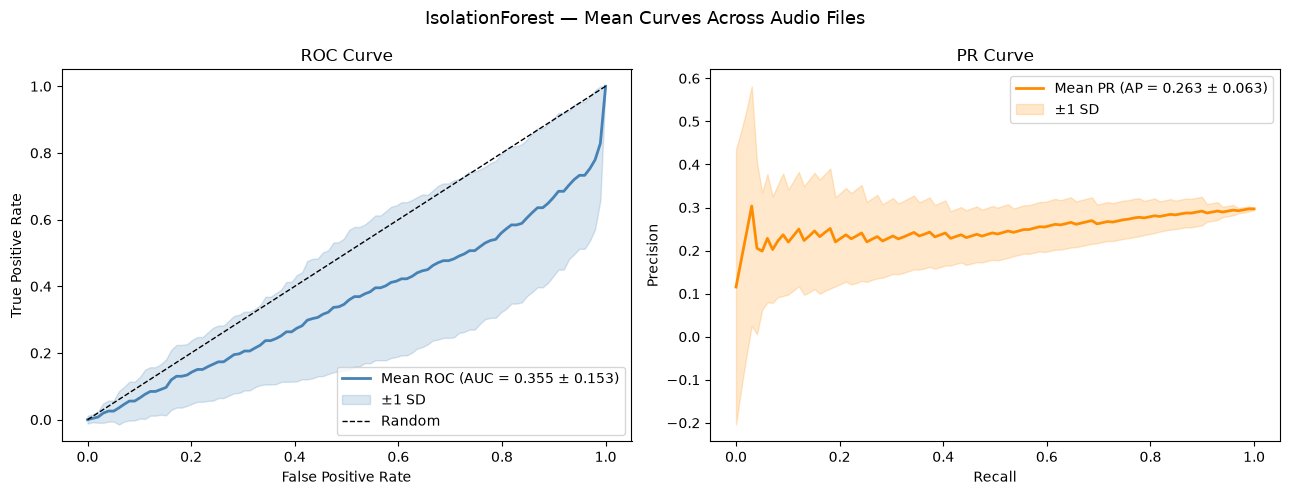

2026-06-26 07:23:03,210 - INFO - Pipeline complete.


In [1]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 0
anomaly_type = "Gunshots" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio,.3)

In [ ]:
""" 
PR Curve
Recall: "Of all actual positives, how many did I find?"
Precision: "Of everything I predicted positive, how many were actually positive?"
"""

In [6]:
file_p = "./AnomalyDetection/Model_Results/IsolationForest/NonUrban/Gunshots/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

2026-06-25 16:54:14,058 - INFO - Starting IsolationForest pipeline | natural=0, anomaly_type=Explosion, window_size=5, test_ratio=0.3, contamination=0.01
2026-06-25 16:54:14,064 - INFO - Loaded 26 audio files
2026-06-25 16:54:14,064 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-25 16:54:30,941 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_10\Explosion\audio_10_Explosion_clips.wav' | window_size: 5
2026-06-25 16:54:47,174 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_11\Exp

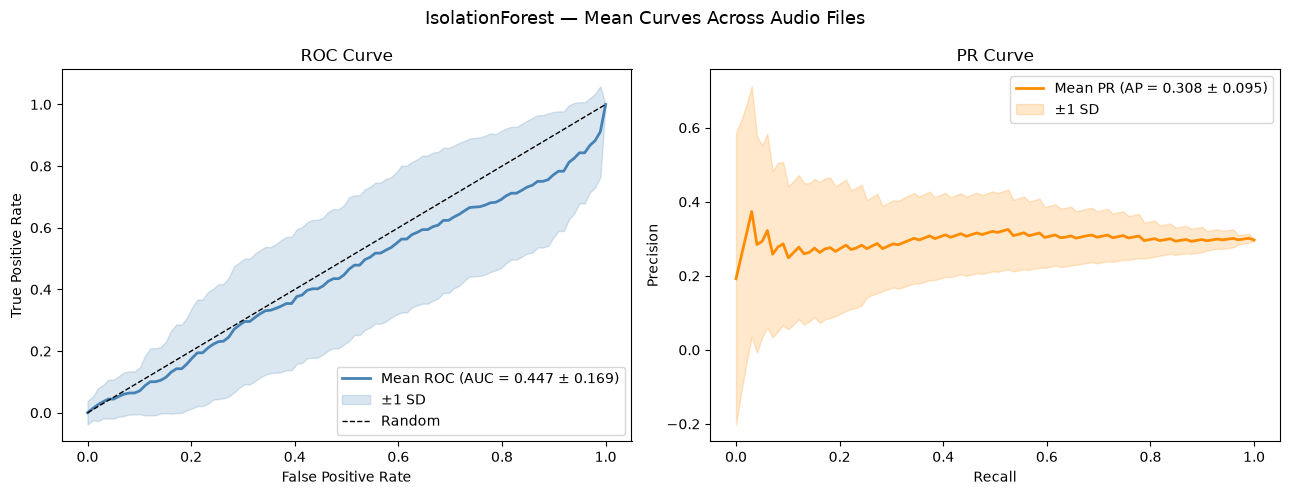

2026-06-25 17:01:23,400 - INFO - Pipeline complete.


In [7]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 0
anomaly_type = "Explosion" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio)

In [11]:
file_p = f"./AnomalyDetection/Model_Results/IsolationForest/NonUrban/{anomaly_type}/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

2026-06-25 17:23:54,895 - INFO - Starting IsolationForest pipeline | natural=0, anomaly_type=UAV, window_size=5, test_ratio=0.3, contamination=0.01
2026-06-25 17:23:54,901 - INFO - Loaded 26 audio files
2026-06-25 17:23:54,902 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_1\UAV\audio_1_UAV_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-25 17:24:11,858 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\NonUrban\audio_10\UAV\audio_10_UAV_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined 

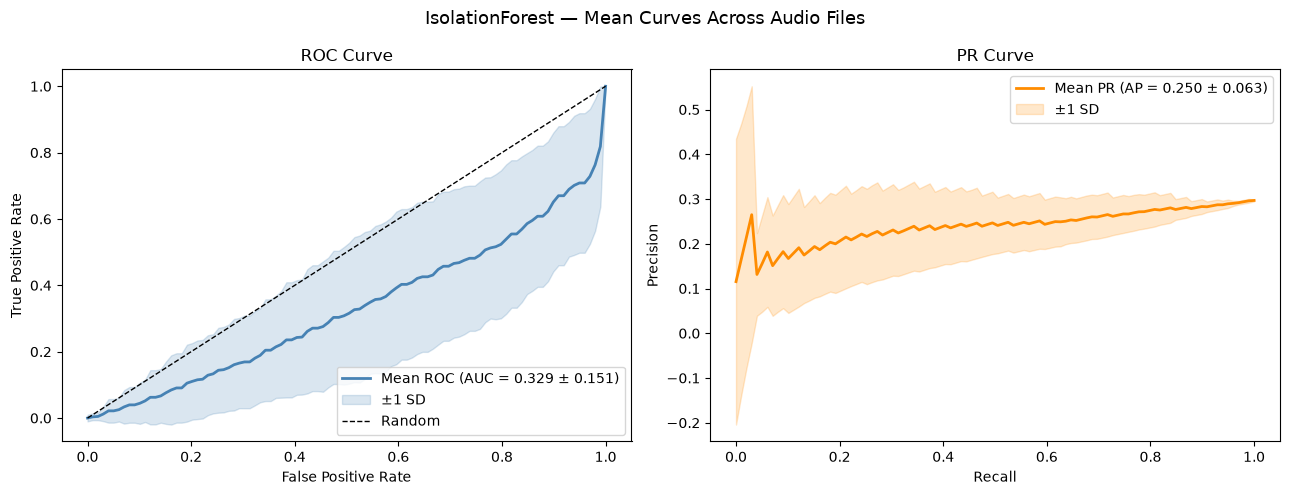

2026-06-25 17:31:34,619 - INFO - Pipeline complete.


In [12]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 0
anomaly_type = "UAV" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio)

In [13]:
file_p = f"./AnomalyDetection/Model_Results/IsolationForest/NonUrban/{anomaly_type}/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

Urban

2026-06-25 17:39:21,594 - INFO - Starting IsolationForest pipeline | natural=1, anomaly_type=Gunshots, window_size=5, test_ratio=0.3, contamination=0.01
2026-06-25 17:39:21,601 - INFO - Loaded 30 audio files
2026-06-25 17:39:21,601 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_1\Gunshots\audio_1_Gunshots_clips.wav' | window_size: 5
2026-06-25 17:39:36,067 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_10\Gunshots\audio_10_Gunshots_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-25 17:39:54,364 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_11\Gunshots\audio_11

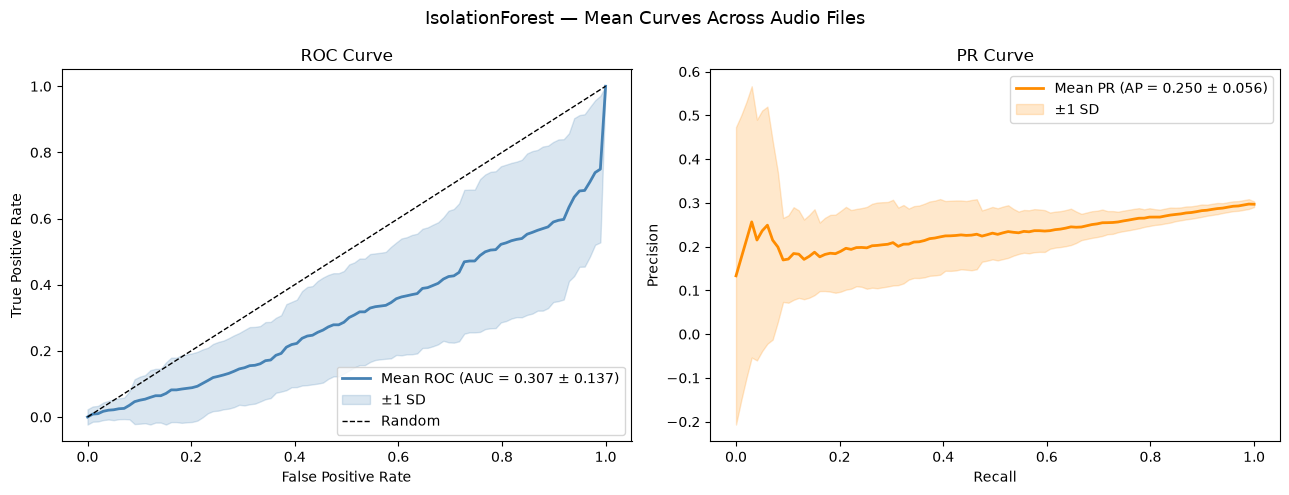

2026-06-25 17:45:08,535 - INFO - Pipeline complete.


In [14]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 1
anomaly_type = "Gunshots" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio)

In [15]:
file_p = f"./AnomalyDetection/Model_Results/IsolationForest/Urban/{anomaly_type}/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

2026-06-25 17:47:09,261 - INFO - Starting IsolationForest pipeline | natural=1, anomaly_type=Explosion, window_size=5, test_ratio=0.3, contamination=0.01
2026-06-25 17:47:09,267 - INFO - Loaded 30 audio files
2026-06-25 17:47:09,267 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_1\Explosion\audio_1_Explosion_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-25 17:47:23,514 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_10\Explosion\audio_10_Explosion_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: P

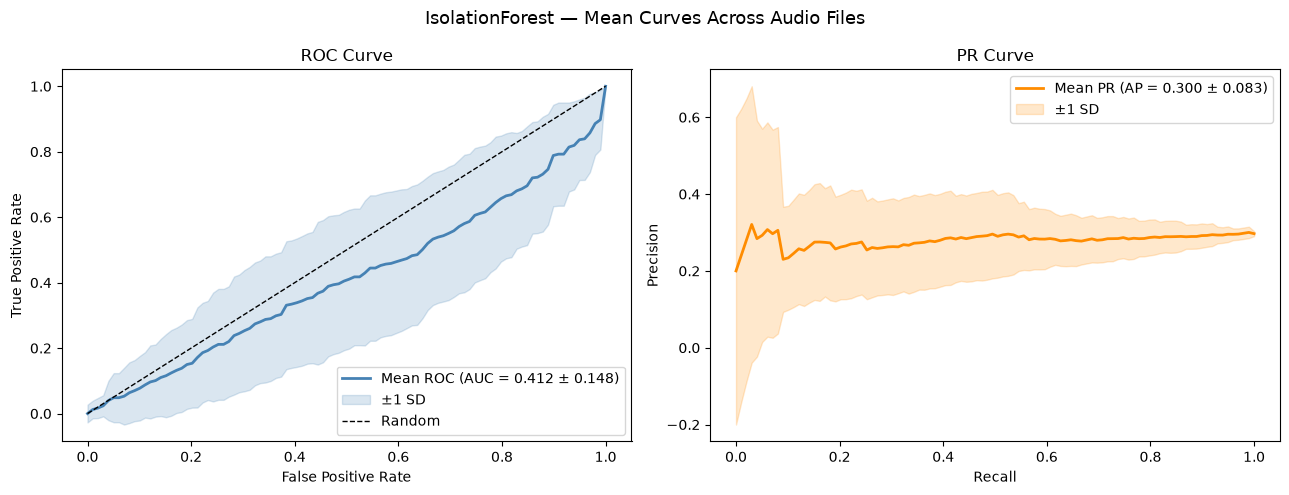

2026-06-25 17:52:51,479 - INFO - Pipeline complete.


In [16]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 1
anomaly_type = "Explosion" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio)

In [17]:
file_p = f"./AnomalyDetection/Model_Results/IsolationForest/Urban/{anomaly_type}/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

2026-06-25 18:00:32,568 - INFO - Starting IsolationForest pipeline | natural=1, anomaly_type=UAV, window_size=5, test_ratio=0.3, contamination=0.01
2026-06-25 18:00:32,574 - INFO - Loaded 30 audio files
2026-06-25 18:00:32,575 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_1\UAV\audio_1_UAV_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-25 18:00:48,764 - INFO - Starting PCA data preparation | file: '.\Data\Audio_Files\Clips\Urban\audio_10\UAV\audio_10_UAV_clips.wav' | window_size: 5
c:\Users\rubie\miniconda3\envs\RFCUNY_R\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and be

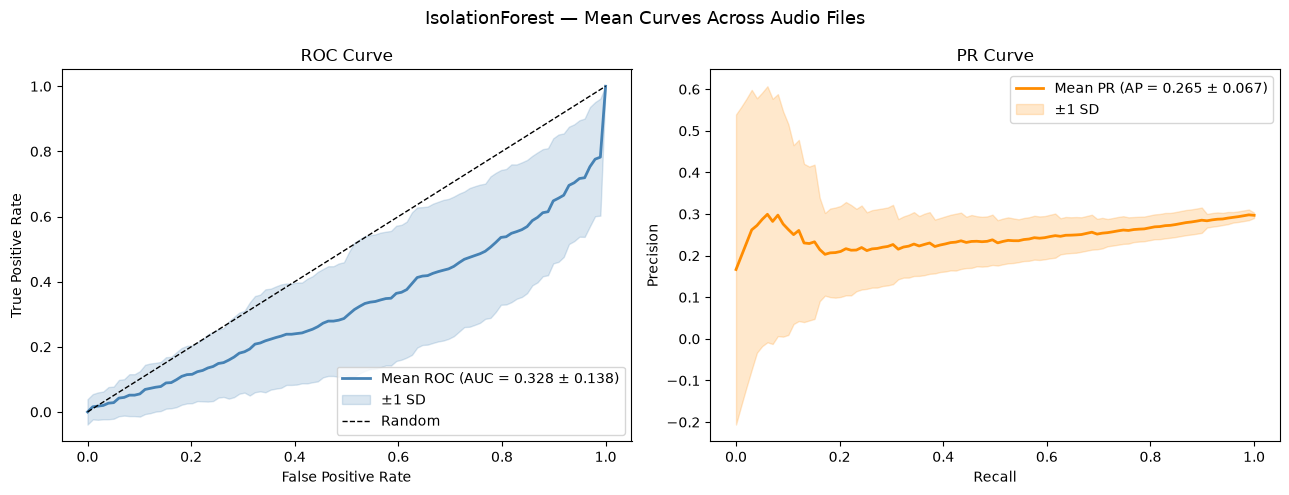

2026-06-25 18:06:22,850 - INFO - Pipeline complete.


In [ ]:
from AnomalyDetection import AnomalyDetection_methods

methods = AnomalyDetection_methods()
natural_bool = 1
anomaly_type = "UAV" 
window_size = 5
test_ratio = 0.3
metrics_df = methods.IsolationForest_pipeline(natural_bool, anomaly_type, window_size, test_ratio)

In [19]:
file_p = f"./AnomalyDetection/Model_Results/IsolationForest/Urban/{anomaly_type}/model_metrics.csv"
metrics_df.to_csv(file_p, index=False)

In [ ]:
""" 
One class support vector machine

Random forest for supervised classification

Contrasting learning: method not anomaly detection.

Try PCA then move on to supervised methods.

------------
Abandon anomaly detection continue with supervised classifications of audio
- Use huggingface model to detect sound
- Then try to extract additional info from sound
"""

In [ ]:
""" 
High false positive rate: Not necessarily bad since we can confirm or deny 
when we try to classify the audio sound

However the issue may be if the False Negative ratio is high since those 
would slip through as normal background noises and not be sent to the second
phase of classification!


Improvement:
Maximize for recall ratio by minimizing false negatives :  
Although percision will fall the false positives can be filtered when we do 
supervised classifications for identifying specific sounds!.
"""

In [ ]:
#work on the pca method, how does it lead to labeling anomaly vs non anomaly
